In [11]:
from sklearn.datasets import load_digits
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [47]:
X,y = load_digits(return_X_y = True)
digits = load_digits()

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

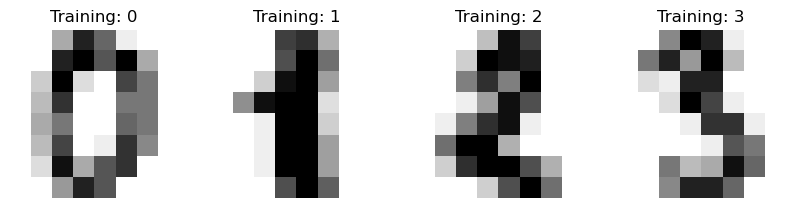

In [12]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

In [16]:
img = X[3].reshape(8,8)

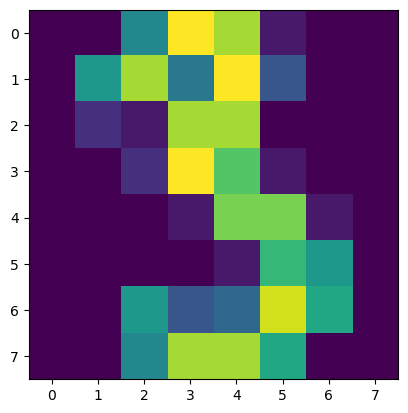

In [17]:
plt.imshow(img)

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = .2 ,random_state=23)

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
lr = LogisticRegression(multi_class='multinomial')

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [35]:
sc = StandardScaler()

In [36]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [37]:
pca = PCA(n_components=10)

In [38]:
X_train_pca = pca.fit_transform(X_train_scaled)

In [39]:
X_test_pca = pca.transform(X_test_scaled)

In [40]:
X_train_pca.shape

(1437, 10)

In [41]:
lr.fit(X_train_pca,y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [42]:
y_pred = lr.predict(X_test_pca)

In [45]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [44]:
accuracy_score(y_test,y_pred)

0.8861111111111111

In [46]:
confusion_matrix(y_test,y_pred)

array([[30,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 29,  2,  0,  1,  1,  0,  0,  5,  2],
       [ 0,  0, 35,  0,  0,  0,  0,  1,  2,  0],
       [ 0,  0,  0, 27,  0,  0,  0,  0,  1,  1],
       [ 0,  0,  0,  0, 38,  0,  0,  1,  1,  0],
       [ 0,  0,  0,  0,  1, 41,  0,  0,  1,  1],
       [ 0,  0,  0,  0,  0,  0, 31,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 27,  1,  0],
       [ 0,  2,  2,  1,  1,  1,  0,  1, 28,  2],
       [ 0,  0,  0,  3,  0,  1,  0,  1,  4, 33]])

In [57]:
lr.predict_proba(X_test_pca[1].reshape(1,10))

array([[5.61499485e-07, 1.94858839e-03, 1.59511903e-08, 3.09928993e-07,
        7.20036244e-04, 1.24206690e-05, 9.93687865e-01, 5.85734065e-08,
        3.62804450e-03, 2.09943256e-06]])